# Project 4 - Neural Radiance Field (NeRF)

In [ ]:
# load libraries
import numpy as np
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from skimage.transform import resize

import cv2
import numpy as np
import glob # for loading multiple files
import viser # visualizations

# imports for part 1
import os
import math
import time
from functools import partial

from PIL import Image # for image loading

# pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


## Part 0: Calibrating Your Camera and Capturing a 3D Scan

### Part 0.1: Calibrating Your Camera

In [ ]:
# calibration pipeline

# starter code from spec
# import cv2
# import numpy as np

# Create ArUco dictionary and detector parameters (4x4 tags)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()

# tag size
tag_size = 0.06 # meters, 0.02 = 2 cm
# 3d coordinates of aruco tag in world frame
obj_pts_single = np.array([
    [0, 0, 0],           # Top-left
    [tag_size, 0, 0],    # Top-right
    [tag_size, tag_size, 0],  # Bottom-right
    [0, tag_size, 0]     # Bottom-left
], dtype = np.float32)

obj_pts = [] # all 3D pts in world frame
img_pts = [] # all 2D pts in image frame

# images = glob.glob('calibration-images/*.JPG') # path to images
images = glob.glob('desk-calibration-images/*.jpg') # path to images, path file ending is case sensitive (e.g. jpg vs JPG are different)

for path in images:
    # load image
    im = cv2.imread(path)
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    # Detect ArUco markers in an image
    # Returns: corners (list of numpy arrays), ids (numpy array)
    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # modify to take in grayscale image

    # Check if any markers were detected
    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.")
        continue
    # Process the detected corners
    # corners: list of length N (number of detected tags)
    #   - each element is a numpy array of shape (1, 4, 2) containing the 4 corner coordinates (x, y)
    # ids: numpy array of shape (N, 1) containing the tag IDs for each detected marker
    # Example: if 3 tags detected, corners will be a list of 3 arrays, ids will be shape (3, 1)
        # loop through all detected markers
    for c in corners:
        img_pts.append(c.reshape(4, 2)) # reshape from (1, 4, 2) to shape: (4,2)
        obj_pts.append(obj_pts_single) # append the same 3D points for each detected marker

# 5. calibrate camera
if len(obj_pts) >= 10:
    print(f"Using {len(obj_pts)} detected tags for calibration")
    img_shape = gray.shape[::-1] # (width, height)
    
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        obj_pts,
        img_pts,
        img_shape,
        None, # initial camera matrix (estimated by OpenCV)
        None # initial distortion coefficients
    )

    print("Calibration successful!")
    print("Camera matrix (intrinsics):\n", camera_matrix) # camera_matrix = K from discussion
    print("Distortion coefficients:\n", dist_coeffs)

else:
    print("No valid markers detected in any image. Calibration unsuccessful.")

In [ ]:
# # test if programs work on spec's sample data
# # calibration pipeline

# # starter code from spec
# # import cv2
# # import numpy as np

# # Create ArUco dictionary and detector parameters (4x4 tags)
# aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
# aruco_params = cv2.aruco.DetectorParameters()

# # tag size
# tag_size = 0.06 # meters, 0.02 = 2 cm
# # 3d coordinates of aruco tag in world frame
# obj_pts_single = np.array([
#     [0, 0, 0],           # Top-left
#     [tag_size, 0, 0],    # Top-right
#     [tag_size, tag_size, 0],  # Bottom-right
#     [0, tag_size, 0]     # Bottom-left
# ], dtype = np.float32)

# obj_pts = [] # all 3D pts in world frame
# img_pts = [] # all 2D pts in image frame

# images = glob.glob('calibration-images/*.JPG') # path to images
# # images = glob.glob('desk-calibration-images/*.jpg') # path to images, path file ending is case sensitive (e.g. jpg vs JPG are different)

# for path in images:
#     # load image
#     im = cv2.imread(path)
#     gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

#     # Detect ArUco markers in an image
#     # Returns: corners (list of numpy arrays), ids (numpy array)
#     corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # modify to take in grayscale image

#     # Check if any markers were detected
#     if ids is None or len(ids) == 0:
#         print(f"No ArUco detected in {path}, skipping.")
#         continue
#     # Process the detected corners
#     # corners: list of length N (number of detected tags)
#     #   - each element is a numpy array of shape (1, 4, 2) containing the 4 corner coordinates (x, y)
#     # ids: numpy array of shape (N, 1) containing the tag IDs for each detected marker
#     # Example: if 3 tags detected, corners will be a list of 3 arrays, ids will be shape (3, 1)
#         # loop through all detected markers
#     for c in corners:
#         img_pts.append(c.reshape(4, 2)) # reshape from (1, 4, 2) to shape: (4,2)
#         obj_pts.append(obj_pts_single) # append the same 3D points for each detected marker

# # 5. calibrate camera
# if len(obj_pts) >= 10:
#     print(f"Using {len(obj_pts)} detected tags for calibration")
#     img_shape = gray.shape[::-1] # (width, height)
    
#     ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
#         obj_pts,
#         img_pts,
#         img_shape,
#         None, # initial camera matrix (estimated by OpenCV)
#         None # initial distortion coefficients
#     )

#     print("Calibration successful!")
#     print("Camera matrix (intrinsics):\n", camera_matrix) # camera_matrix = K from discussion
#     print("Distortion coefficients:\n", dist_coeffs)

# else:
#     print("No valid markers detected in any image. Calibration unsuccessful.")

### Part 0.3: Estimating Camera Pose

In [ ]:
# visualize
server = viser.ViserServer(share=True)

obj_images = glob.glob("octo-images/*.jpg")
obj_images = sorted(obj_images)

# for part 0.4
undistorted_images = []
c2w_matrices = []

# for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
for i, path in enumerate(obj_images): # rn images = calibration images
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
        continue

    # use first marker
    img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

    # outputs = solvePnP(inputs)
    success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
    if not success:
        print(f"PnP failed for {path}, skipping.") # check what's happening
        continue

    R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
    t = tvec.reshape(3, 1)
    R_wc = R.T
    t_wc = -R.T @ t
    c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

    # undistort the image
    undistorted = cv2.undistort(img, camera_matrix, dist_coeffs)
    # convert BGR to RGB for NeRF
    undistorted = undistorted[:, :, ::-1]
    # append/save
    undistorted_images.append(undistorted)
    c2w_full = np.eye(4)
    c2w_full[:3, :4] = c2w
    c2w_matrices.append(c2w_full)

    # convert BGR to RGB for viser
    img_rgb = img[:, :, ::-1]

    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
        aspect=gray.shape[1] / gray.shape[0],
        scale=0.02,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=img_rgb
    )


In [ ]:
# # visualize
# server = viser.ViserServer(share=True)

# obj_images = glob.glob("lafufu-images/*.JPG")
# obj_images = sorted(obj_images)

# # for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
# for i, path in enumerate(obj_images): # rn images = calibration images
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
#     if ids is None or len(ids) == 0:
#         print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
#         continue

#     # use first marker
#     img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

#     # outputs = solvePnP(inputs)
#     success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
#     if not success:
#         print(f"PnP failed for {path}, skipping.") # check what's happening
#         continue

#     R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
#     t = tvec.reshape(3, 1)
#     R_wc = R.T
#     t_wc = -R.T @ t
#     c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

#     # convert BGR to RGB for viser
#     img_rgb = img[:, :, ::-1]

#     server.scene.add_camera_frustum(
#         f"/cameras/{i}",
#         fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
#         aspect=gray.shape[1] / gray.shape[0],
#         scale=0.02,
#         wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
#         position=c2w[:3, 3],
#         image=img_rgb
#     )


### Part 0.4: Undistorting images and creating a dataset

In [ ]:
# after for loop to solve PnP + viser
undistorted_images = np.array(undistorted_images) # (N, H, W, 3)
c2w_matrices = np.array(c2w_matrices) # (N, 4, 4)

# train/test split
# train/val/test = 80/10/10
N = len(undistorted_images)
idx_train = int(0.8 * N)
idx_val = int(0.9 * N)

images_train = undistorted_images[:idx_train]
c2ws_train   = c2w_matrices[:idx_train]

images_val   = undistorted_images[idx_train:idx_val]
c2ws_val     = c2w_matrices[idx_train:idx_val]

c2ws_test    = c2w_matrices[idx_val:]

# use average of fx and fy to extract focal length
focal = float((camera_matrix[0, 0] + camera_matrix[1, 1]) / 2)

# from spec to save dataset
# Package your data (keep images in 0-255 range, they'll be normalized when loaded)
np.savez(
    'my_data.npz',
    images_train=images_train,    # (N_train, H, W, 3)
    c2ws_train=c2ws_train,        # (N_train, 4, 4)
    images_val=images_val,        # (N_val, H, W, 3)
    c2ws_val=c2ws_val,            # (N_val, 4, 4)
    c2ws_test=c2ws_test,          # (N_test, 4, 4)
    focal=focal                   # float
)

print("Saved dataset to my_data.npz")

## Part 1: Fit a Neural Field to a 2D Image


--- RUN: PE L=4, width=32 ---
iter 1/2000: loss=0.100994 -> saved part1-results/recon_pe4_w32_iter0001.png
iter 200/2000: loss=0.018029, val_psnr=18.50 dB -> saved part1-results/recon_pe4_w32_iter0200.png
iter 400/2000: loss=0.009217, val_psnr=20.89 dB -> saved part1-results/recon_pe4_w32_iter0400.png
iter 600/2000: loss=0.005981, val_psnr=22.45 dB -> saved part1-results/recon_pe4_w32_iter0600.png
iter 800/2000: loss=0.005087, val_psnr=22.80 dB -> saved part1-results/recon_pe4_w32_iter0800.png
iter 1000/2000: loss=0.004677, val_psnr=23.19 dB -> saved part1-results/recon_pe4_w32_iter1000.png
iter 1200/2000: loss=0.004820, val_psnr=23.00 dB -> saved part1-results/recon_pe4_w32_iter1200.png
iter 1400/2000: loss=0.004769, val_psnr=23.28 dB -> saved part1-results/recon_pe4_w32_iter1400.png
iter 1600/2000: loss=0.004485, val_psnr=23.50 dB -> saved part1-results/recon_pe4_w32_iter1600.png
iter 1800/2000: loss=0.004248, val_psnr=23.62 dB -> saved part1-results/recon_pe4_w32_iter1800.png
iter 

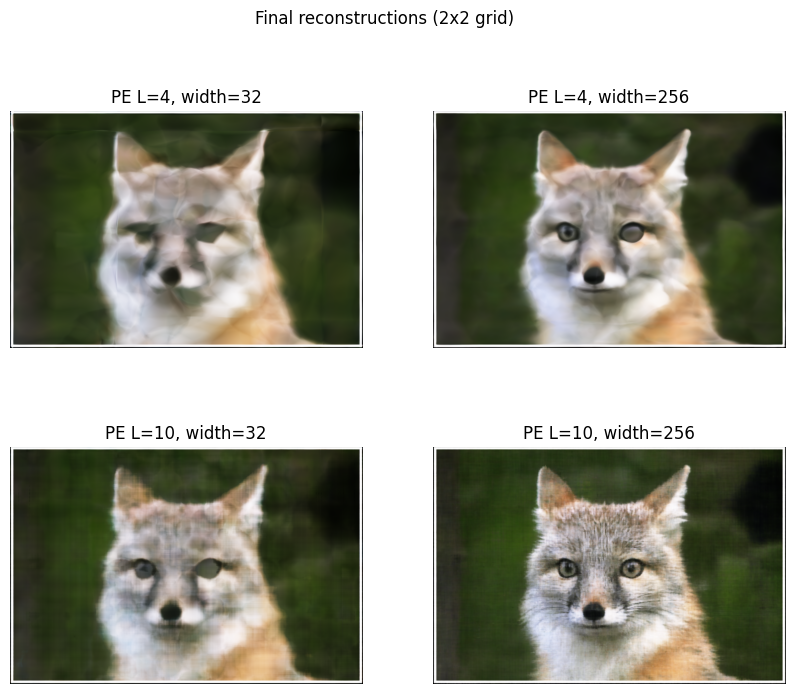

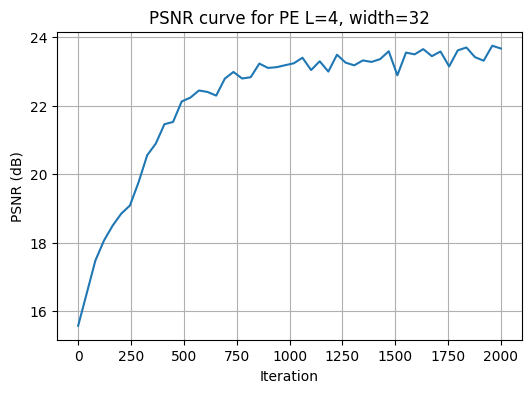

Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).


In [8]:
# for part 1
image_path = "part1-images/fox.jpg" # path to our image
device = torch.device("mps" if torch.mps.is_available() else "cpu") # using mps for m1 mac
out_dir = "part1-results" # new folder to save results
os.makedirs(out_dir, exist_ok = True)

# training hyperparameters
num_iters = 2000 # 1000-3000 iterations recommended
batch_size = 10000 # sample pixels per iteration
lr = 1e-2 # use adam optimizer, PSNR instead of MSE
log_every = 200 # save recon every `log_every` iterations

# hyperparameters
default_width = 256
default_layers = 3 # number of hidden linear layers (as in figure)
default_pe_L = 10  # max frequency L (PE will use 2^0..2^(L-1))

# helper functions
# convert image to RGB and return as a np array
def load_image_np(path):
    im = Image.open(path).convert("RGB")
    arr = np.array(im).astype(np.uint8)
    return arr

def img_to_coords_and_colors(img_np):
    H, W = img_np.shape[:2]
    # create pixel coordinates (x,y) convention: center or top-left? Here we normalize by width/height
    xs = np.arange(W)
    ys = np.arange(H)
    xv, yv = np.meshgrid(xs, ys)
    coords = np.stack([xv, yv], axis=-1).reshape(-1, 2) # (H*W, 2)
    colors = img_np.reshape(-1, 3) / 255.0 # normalize to [0,1]
    return coords.astype(np.float32), colors.astype(np.float32), H, W

def compute_psnr(mse):
    # image normalized [0,1]
    if mse <= 0:
        return float("inf")
    return 10.0 * math.log10(1.0 / mse) # PSNR formula from spec

# positional encoding
class PositionalEncoding2D(nn.Module):
    def __init__(self, L):
        """
        L: number of frequencies. Produces features:
           [x, y, sin(2^0 pi x), cos(2^0 pi x), ..., sin(2^(L-1) pi x), cos(2^(L-1) pi x),
                  sin(2^0 pi y), cos(2^0 pi y), ..., sin(2^(L-1) pi y), cos(2^(L-1) pi y)]
           The original coordinate (x,y) is kept as well.
        """
        super().__init__()
        self.L = L
        # precompute scales: 2^k * pi
        self.register_buffer("scales", torch.tensor([ (2**k) * math.pi for k in range(L) ], dtype=torch.float32)) # store frequency bands

    def forward(self, coords_norm): # expand dimensionality by applying sinusoidal functions
        # coords_norm: (N, 2) where coords are normalized to [0,1]
        x = coords_norm[..., 0:1]  # (N,1)
        y = coords_norm[..., 1:2]
        out = [x, y]
        for s in self.scales: # apply sinusoidal functions to input coordinates
            out.append(torch.sin(x * s))
            out.append(torch.cos(x * s))
        for s in self.scales:
            out.append(torch.sin(y * s))
            out.append(torch.cos(y * s))
        return torch.cat(out, dim=-1)  # (N, 2 + 4*L)

# implement MLP network
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, width=256, hidden_layers=3): # hidden layer width, 3 hidden layers
        super().__init__()
        layers = []
        last = in_dim
        for i in range(hidden_layers):
            layers.append(nn.Linear(last, width))
            layers.append(nn.ReLU(inplace=True))
            last = width
        # final linear to 3 channels
        layers.append(nn.Linear(last, 3))
        layers.append(nn.Sigmoid()) # sigmoid activation, outputs in [0,1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# dataloader
class RandomPixelDataset(Dataset):
    def __init__(self, coords, colors):
        """
        coords: (Npix, 2) in pixel coords (0..W-1, 0..H-1)
        colors: (Npix, 3) normalized [0,1]
        """
        self.coords = coords
        self.colors = colors
        self.N = coords.shape[0]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        return self.coords[idx], self.colors[idx]

# run function for just a single training run
def train_single_run(image_path,
                     pe_L=10,
                     width=256,
                     hidden_layers=3,
                     num_iters=2000,
                     batch_size=10000, # staff on Ed recommends a batch size of 10k pixels
                     lr=1e-2, # Ed-recommended learning rate
                     log_every=200,
                     out_dir="part1-results"):
    np_img = load_image_np(image_path)
    coords, colors, H, W = img_to_coords_and_colors(np_img)
    Npix = coords.shape[0]

    # normalize coords to [0,1]
    coords_norm = coords.copy()
    coords_norm[:, 0] = coords_norm[:, 0] / (W - 1) # x / (W-1)
    coords_norm[:, 1] = coords_norm[:, 1] / (H - 1) # y / (H-1)

    device_local = device

    # prepare PE and model
    pe = PositionalEncoding2D(pe_L).to(device_local)
    # input dimension after PE == 2 + 4*L
    in_dim = 2 + 4 * pe_L
    model = SimpleMLP(in_dim, width=width, hidden_layers=hidden_layers).to(device_local)

    # optimizer + loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # use adam optimizer
    criterion = nn.MSELoss()

    # prepare dataset arrays as tensors (we will sample indices each iteration)
    coords_norm_t = torch.from_numpy(coords_norm).to(device_local)   # (Npix,2)
    colors_t = torch.from_numpy(colors).to(device_local)             # (Npix,3)

    losses = []
    psnrs = []
    start_time = time.time()

    # for monitoring, create a fixed validation set (1000 random pixels)
    rng = np.random.RandomState(123)
    val_idx = rng.choice(Npix, size=min(1000, Npix), replace=False)
    val_coords = coords_norm_t[val_idx]
    val_colors = colors_t[val_idx]

    # main training loop
    for it in range(1, num_iters + 1):
        # sample pixel indices
        idx = np.random.randint(0, Npix, size=batch_size)
        batch_coords = coords_norm_t[idx]  # (batch,2)
        batch_colors = colors_t[idx]       # (batch,3)

        # forward
        pe_feats = pe(batch_coords)        # (batch, in_dim)
        preds = model(pe_feats)            # (batch,3)

        loss = criterion(preds, batch_colors)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # validation PSNR every iteration or per log
        if it % max(1, log_every // 5) == 0:
            with torch.no_grad():
                val_preds = model(pe(pe_coords := val_coords))
                val_mse = F.mse_loss(val_preds, val_colors).item()
                val_psnr = compute_psnr(val_mse)
                psnrs.append(val_psnr)

        # save reconstructions periodically
        if it % log_every == 0 or it == 1 or it == num_iters:
            with torch.no_grad():
                # reconstruct full image (may be slow for large images)
                all_pe = pe(coords_norm_t)  # (Npix, in_dim)
                all_preds = model(all_pe).cpu().numpy()  # (Npix,3)
                recon = (all_preds.reshape(H, W, 3) * 255.0).clip(0, 255).astype(np.uint8)
                out_img_path = os.path.join(out_dir, f"recon_pe{pe_L}_w{width}_iter{it:04d}.png")
                Image.fromarray(recon).save(out_img_path)
                msg = f"iter {it}/{num_iters}: loss={loss.item():.6f}"
                if 'val_psnr' in locals():
                    msg += f", val_psnr={val_psnr:.2f} dB"
                msg += f" -> saved {out_img_path}"
                print(msg)


    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f}s")

    # final full recon
    with torch.no_grad():
        all_pe = pe(coords_norm_t)
        all_preds = model(all_pe).cpu().numpy()
        recon = (all_preds.reshape(H, W, 3) * 255.0).clip(0, 255).astype(np.uint8)
        final_path = os.path.join(out_dir, f"final_recon_pe{pe_L}_w{width}.png")
        Image.fromarray(recon).save(final_path)

    # return logs and final image path
    return {
        "losses": losses,
        "psnrs": psnrs,
        "final_image_path": final_path,
        "recon_paths": sorted([p for p in os.listdir(out_dir) if p.startswith(f"recon_pe{pe_L}_w{width}")])
    }

# 2x2 grid and plot PSNR curve + 2x2 images helper function
def run_grid_and_plot(image_path,
                      pe_list=[4, 10],
                      width_list=[32, 256],
                      num_iters=2000,
                      batch_size=10000,
                      lr=1e-2,
                      log_every=500):
    results = {}
    for pe_L in pe_list:
        for width in width_list:
            print(f"\n--- RUN: PE L={pe_L}, width={width} ---")
            res = train_single_run( # calls train_single_run 4 times using different hyperparameters
                image_path,
                pe_L=pe_L,
                width=width,
                hidden_layers=3,
                num_iters=num_iters,
                batch_size=batch_size,
                lr=lr,
                log_every=log_every,
                out_dir=out_dir
            )
            results[(pe_L, width)] = res

    # Plot last reconstructions in a 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.flatten()
    keys = list(results.keys())
    for i, k in enumerate(keys[:4]):
        path = results[k]["final_image_path"]
        img = Image.open(path)
        axs[i].imshow(img)
        axs[i].set_title(f"PE L={k[0]}, width={k[1]}")
        axs[i].axis("off")
    plt.suptitle("Final reconstructions (2x2 grid)")
    plt.show()

    # Plot PSNR curve for first experiment
    first_key = keys[0]
    psnrs = results[first_key]["psnrs"]
    plt.figure(figsize=(6,4))
    iterations = np.linspace(0, num_iters, len(psnrs))
    plt.plot(iterations, psnrs)
    plt.xlabel("Iteration")
    plt.ylabel("PSNR (dB)")
    plt.title(f"PSNR curve for PE L={first_key[0]}, width={first_key[1]}")
    plt.grid(True)
    plt.show()

    return results

# test run
if __name__ == "__main__":
    # test run to check functionality
    # res = train_single_run(image_path, pe_L=10, width=256, hidden_layers=3, num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every, out_dir=out_dir)

    # run the 2x2 grid (train 4 models sequentially)
    grid_res = run_grid_and_plot(image_path, pe_list=[4,10], width_list=[32,256], num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every)

    print("Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).")



--- RUN: PE L=4, width=32 ---
iter 1/2000: loss=0.055929 -> saved part1-results/recon_pe4_w32_iter0001.png
iter 200/2000: loss=0.013722, val_psnr=18.66 dB -> saved part1-results/recon_pe4_w32_iter0200.png
iter 400/2000: loss=0.012600, val_psnr=19.04 dB -> saved part1-results/recon_pe4_w32_iter0400.png
iter 600/2000: loss=0.011281, val_psnr=19.39 dB -> saved part1-results/recon_pe4_w32_iter0600.png
iter 800/2000: loss=0.010970, val_psnr=19.65 dB -> saved part1-results/recon_pe4_w32_iter0800.png
iter 1000/2000: loss=0.010332, val_psnr=19.90 dB -> saved part1-results/recon_pe4_w32_iter1000.png
iter 1200/2000: loss=0.009630, val_psnr=19.82 dB -> saved part1-results/recon_pe4_w32_iter1200.png
iter 1400/2000: loss=0.009731, val_psnr=19.98 dB -> saved part1-results/recon_pe4_w32_iter1400.png
iter 1600/2000: loss=0.010152, val_psnr=19.87 dB -> saved part1-results/recon_pe4_w32_iter1600.png
iter 1800/2000: loss=0.010137, val_psnr=20.00 dB -> saved part1-results/recon_pe4_w32_iter1800.png
iter 

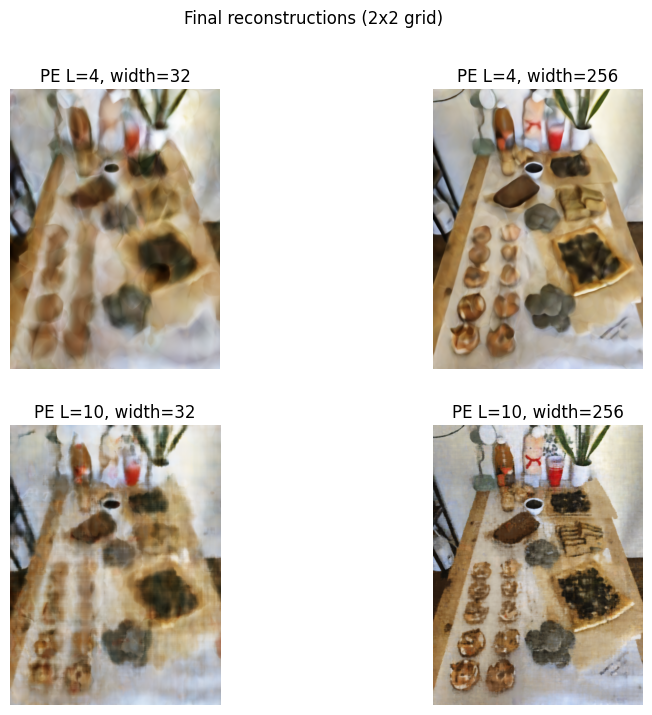

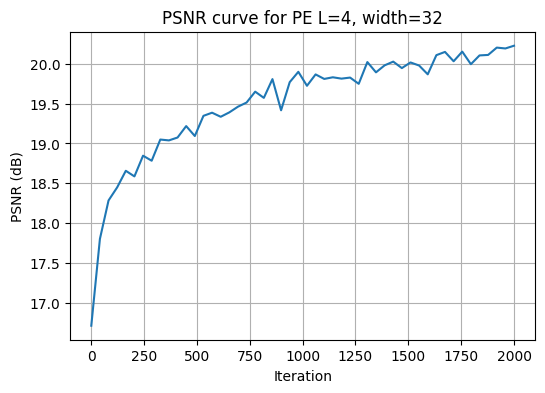

Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).


In [9]:
# testing on an image of my choice
image_path = "part1-images/home_cafe.jpg" # path to new image

if __name__ == "__main__":
    # test run to check functionality
    # res = train_single_run(image_path, pe_L=10, width=256, hidden_layers=3, num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every, out_dir=out_dir)

    # run the 2x2 grid (train 4 models sequentially)
    grid_res = run_grid_and_plot(image_path, pe_list=[4,10], width_list=[32,256], num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every)

    print("Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).")


## Part 2: Fit a Neural Radiance Field from Multi-view Images

In [12]:
# 2d to neural radience field
# use inverse rendering from multi-view calibrated images

# sepc code to parse data (from lego dataset)
data = np.load(f"lego_200x200.npz")

# Training images: [100, 200, 200, 3]
images_train = data["images_train"] / 255.0

# Cameras for the training images 
# (camera-to-world transformation matrix): [100, 4, 4]
c2ws_train = data["c2ws_train"]

# Validation images: 
images_val = data["images_val"] / 255.0

# Cameras for the validation images: [10, 4, 4]
# (camera-to-world transformation matrix): [10, 200, 200, 3]
c2ws_val = data["c2ws_val"]

# Test cameras for novel-view video rendering: 
# (camera-to-world transformation matrix): [60, 4, 4]
c2ws_test = data["c2ws_test"]

# Camera focal length
focal = data["focal"]  # float

### Part 2.1: Create Rays from Cameras

In [13]:
# camera to world space function
def transform(c2w, x_c):
    """
    trasnform points from camera coordinates to world coordinates
    
    inputs:
        c2w (torch.Tensor): camera-to-world matrix, shape (B, 4, 4) or (4, 4)
        x_c (torch.Tensor): pts in camera coordinates, shape (B, N, 3) or (N, 3)
        
    output:
        torch.Tensor: pts in world coordinates, shape (B, N, 3) or (N, 3)
    """
    # 1. add homogeneous coordinate (w=1)
    ones = torch.ones_like(x_c[..., :1]) 
    x_c_hom = torch.cat([x_c, ones], dim=-1)
    
    # 2. apply transformation
    # want to multiply (..., 4, 4) @ (..., 4, N)
    # permute x_c_hom to (..., 4, N)
    x_c_hom_perm = x_c_hom.permute(0, 2, 1)
    
    # perform matrix multiplication: (..., 4, 4) @ (..., 4, N) -> (..., 4, N)
    if c2w.dim() == 2:
        c2w = c2w.unsqueeze(0) # (1, 4, 4)
    if x_c_hom_perm.dim() == 2:
        x_c_hom_perm = x_c_hom_perm.unsqueeze(0) # (1, 4, N)
        
    x_w_hom_perm = c2w @ x_c_hom_perm
    
    # 3. permute back and de-homogenize
    x_w_hom = x_w_hom_perm.permute(0, 2, 1)  # Shape: (..., N, 4)
    
    # divide by the w-coordinate
    x_w = x_w_hom[..., :3] / x_w_hom[..., 3:4]
    
    return x_w.squeeze() # squeeze to remove batch dim if it was added

# pixel coordinate back to camera coordinate system
def pixel_to_camera(K, uv, s = 1.0):
    """
    2D pixel coordinates to 3D camera coordinates
    
    inputs:
        K (torch.Tensor): intrinsic matrix, shape (B, 3, 3) or (3, 3)
        uv (torch.Tensor): pixel coordinates, shape (B, N, 2) or (N, 2)
        s (float or torch.Tensor): depth(s), broadcastable to (B, N, 1)
        
    output:
        torch.Tensor: 3D pts in camera coordinates, shape (B, N, 3) or (N, 3)
    """
    # extract intrinsics (making sure they can be broadcast)
    fx = K[..., 0, 0].unsqueeze(-1)  
    fy = K[..., 1, 1].unsqueeze(-1)
    ox = K[..., 0, 2].unsqueeze(-1)
    oy = K[..., 1, 2].unsqueeze(-1)
    
    u = uv[..., 0:1]
    v = uv[..., 1:2]
    
    # inverse projection formulas
    x_c = s * (u - ox) / fx
    y_c = s * (v - oy) / fy
    
    # z_c = s from spec
    # a tensor of s with the same shape as x_c
    if isinstance(s, float):
        z_c = torch.full_like(x_c, s)
    else:
        z_c = s * torch.ones_like(x_c)

    return torch.cat([x_c, y_c, z_c], dim=-1)

# convert pixel coordinate to a ray with origin and normalized direction
def pixel_to_ray(K, c2w, uv):
    """
    calculate ray origins and directions for pixels
    
    inputs:
        K (torch.Tensor): intirnsic matrix, shape (3, 3)
        c2w (torch.Tensor): camera-to-world matrix, shape (4, 4)
        uv (torch.Tensor): pixel coordinates, shape (N, 2)
        
    output:
        (torch.Tensor, torch.Tensor): 
            - r_o: rya origins, shape (N, 3)
            - r_d: ray directions, shape (N, 3)
    """
    N = uv.shape[0]
    
    # 1. get ray origin (r_o)
    # camera's position = translation t part of c2w 
    r_o_world = c2w[:3, 3]
    r_o = r_o_world.unsqueeze(0).expand(N, -1)
    
    # 2. account for pixel center
    uv_centered = uv + 0.5 # offset by 0.5 to get the pixel center
    
    # 3. find 3D point in camera space (at s = 1)
    # add a batch dimension (1) for pixel_to_camera
    p_cam = pixel_to_camera(K.unsqueeze(0), uv_centered.unsqueeze(0), s=1.0) # (1, N, 3)
    
    # 4. transform pt from camera space to world space
    # add a batch dimension (1) for transform()
    p_world = transform(c2w.unsqueeze(0), p_cam) # (1, N, 3)
    p_world = p_world.squeeze(0) # (N, 3)
    
    # 5. compute ray direction (r_d)
    # r_d = p_world - r_o 
    r_d_unnormalized = p_world - r_o
    r_d = F.normalize(r_d_unnormalized, dim=-1)  # Shape: (N, 3)
    
    return r_o, r_d

### Part 2.2: Sampling

In [14]:
def sample_rays(images, c2ws, K, n_rays_to_sample):
    """
    sample rays from images
    
    inputs:
        images (torch.Tensor): training images, shape (N_img, H, W, 3)
        c2ws (torch.Tensor): camera-to-world matrices, shape (N_img, 4, 4)
        K (torch.Tensor): camera intrinsic matrix, shape (3, 3)
        n_rays_to_sample (int): The number of rays to sample (batch size)
        
    output:
        (torch.Tensor, torch.Tensor, torch.Tensor):
            - r_o: ray origins, shape (n_rays_to_sample, 3)
            - r_d: ray directions, shape (n_rays_to_sample, 3)
            - gt_colors: ground-truth pixel colors, shape (n_rays_to_sample, 3)
    """
    N_img, H, W = images.shape[:3]
    
    # 1. get random image indices
    # pick n_rays_to_sample (input parameter) random images (with replacement)
    img_indices = torch.randint(0, N_img, (n_rays_to_sample,), device=images.device)
    
    # 2. get random pixel coordinates (u, v)
    u_coords = torch.randint(0, W, (n_rays_to_sample,), device=images.device)
    v_coords = torch.randint(0, H, (n_rays_to_sample,), device=images.device)
    
    # 3. corresponding camera-to-world matrices
    batch_c2ws = c2ws[img_indices]
    
    # 4. corresponding ground-truth colors
    # use (v, u) indices to index into (H, W)
    gt_colors = images[img_indices, v_coords, u_coords]
    
    # 5. create (u, v) pixel coordinate tensor
    uv_coords = torch.stack([u_coords, v_coords], dim=-1)
    
    # 6. conver pixels to rays
    all_r_o = []
    all_r_d = []
    
    # might need to batch to make faster?
    for i in range(n_rays_to_sample):
        r_o, r_d = pixel_to_ray(K, batch_c2ws[i], uv_coords[i:i+1]) # a (1, 2) tensor
        
        all_r_o.append(r_o)
        all_r_d.append(r_d)
        
    r_o = torch.cat(all_r_o, dim=0) # (n_rays_to_sample, 3)
    r_d = torch.cat(all_r_d, dim=0) # (n_rays_to_sample, 3)

    return r_o, r_d, gt_colors

def sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True):
    """
    sample 3D points along rays using stratified sampling
    
    inputs:
        r_o: ray origins, shape (N_rays, 3)
        r_d: ray directions, shape (N_rays, 3)
        n_samples (int): number of points to sample per ray (e.g., 64)
        near (float): near bound for sampling (e.g., 2.0)
        far (float): far bound for sampling (e.g., 6.0)
        perturb (bool): if true, use stratified (random) sampling 
                        if false, use uniform (midpoint) sampling
                        
    output:
        (torch.Tensor, torch.Tensor):
            - points_3d: the sampled 3D points, shape (N_rays, n_samples, 3)
            - t_vals: the 't' values for each point, shape (N_rays, n_samples)
    """
    N_rays = r_o.shape[0]
    
    # 1. create the bins
    t_bin_edges = torch.linspace(near, far, n_samples + 1, device=r_o.device)
    
    # bin starts and ends
    t_bin_starts = t_bin_edges[:-1]  # (n_samples)
    t_bin_ends = t_bin_edges[1:]    # (n_samples)
    
    # calculate the width of each bin
    bin_width = t_bin_ends - t_bin_starts
    
    if perturb:
        # 2. add random perturbation but only in training (stratified sampling)
        rand = torch.rand(N_rays, n_samples, device=r_o.device)
        
        # t_vals = bin_start + random_offset_within_bin
        t_vals = t_bin_starts.expand(N_rays, -1) + rand * bin_width
    else:
        # 3. no perturbation (e.g., for validation/rendering)
        # midpoint of each bin
        t_vals = (t_bin_starts + t_bin_ends) / 2.0
        t_vals = t_vals.expand(N_rays, -1) # (N_rays, n_samples)

    # 4. 3D points
    # x = R_o + R_d * t
    
    r_o_expanded = r_o.unsqueeze(1)
    r_d_expanded = r_d.unsqueeze(1)
    t_vals_expanded = t_vals.unsqueeze(2)
    
    points_3d = r_o_expanded + r_d_expanded * t_vals_expanded # formula for x
    
    return points_3d, t_vals

### Part 2.3: Putting the Dataloading All Together

In [ ]:
# need to implement Dataloader to use in spec code

class RaysData:
    """
    this class implements the dataloader logic for sampling rays, pre-computes all rays and pixels for efficient sampling
    """
    def __init__(self, images, c2ws, K):
        """
        inputs:
            images (torch.Tensor): images, shape (N_img, H, W, 3)
            c2ws (torch.Tensor): camera-to-world matrices, (N_img, 4, 4)
            K (torch.Tensor): intrinsic matrix, (3, 3)
        """
        super().__init__()
        self.images = images
        self.c2ws = c2ws
        self.K = K
        self.N_img, self.H, self.W = images.shape[:3]
        
        print(f"Loading RaysData: {self.N_img} images, {self.H}x{self.W} resolution.")
        
        # precomputation: create a grid of (u, v) integer coordinates
        y_coords, x_coords = torch.meshgrid(
            torch.arange(self.H, dtype=torch.float32, device=device),
            torch.arange(self.W, dtype=torch.float32, device=device),
            indexing='ij'
        )
        # (H, W, 2) -> (H * W, 2)
        # grid is for one image, will be used for all
        uv_grid_flat = torch.stack([x_coords, y_coords], dim=-1).reshape(-1, 2)
        
        all_rays_o = []
        all_rays_d = []
        all_pixels = []
        all_uvs = []

        # loop through each image to generate all its rays
        for i in range(self.N_img):
            c2w = self.c2ws[i]
            
            # use pixel_to_ray to get origins and directions
            # for all pixels in this one image
            r_o, r_d = pixel_to_ray(self.K, c2w, uv_grid_flat)
            
            # get pixel colors for this image
            pixels = self.images[i].reshape(-1, 3)
            
            all_rays_o.append(r_o)
            all_rays_d.append(r_d)
            all_pixels.append(pixels)
            # store integer (u,v) coordinates for the assert check
            all_uvs.append(uv_grid_flat.to(torch.int64)) 

        # combine all rays and pixels into large tensors
        self.rays_o = torch.cat(all_rays_o, dim=0).to(device)
        self.rays_d = torch.cat(all_rays_d, dim=0).to(device)
        self.pixels = torch.cat(all_pixels, dim=0).to(device)
        self.uvs = torch.cat(all_uvs, dim=0).to(device)
        
        self.N_total_rays = self.rays_o.shape[0]
        print(f"Pre-computed {self.N_total_rays} total rays.")

    def sample_rays(self, n_rays_to_sample):
        """
        samples a random batch of rays from all pre-computed rays.
        """
        # random indices
        indices = torch.randint(0, self.N_total_rays, (n_rays_to_sample,), device=device)
        
        # return the sampled rays and their corresponding colors
        return self.rays_o[indices], self.rays_d[indices], self.pixels[indices]

In [ ]:
# testing, using code 1 from spec part
data = np.load("lego_200x200.npz")
images_train = data["images_train"]
c2ws_train = data["c2ws_train"]
K = data["focal"]

# create intrinsic matrix K
H, W = images_train.shape[1:3]
K_matrix = np.array([
    [K, 0, W/2],
    [0, K, H/2],
    [0, 0, 1]
], dtype=np.float32)

# convert to Tensors
images_train_t = torch.from_numpy(images_train / 255.0).float().to(device)
c2ws_train_t = torch.from_numpy(c2ws_train).float().to(device)
K_t = torch.from_numpy(K_matrix).float().to(device)

# --- You Need to Implement These ---
dataset = RaysData(images_train_t, c2ws_train_t, K_t) # [cite: 240]
rays_o, rays_d, pixels = dataset.sample_rays(100) # [cite: 241]

# define sample parameters
n_samples = 64 
near = 2.0
far = 6.0

points_3d, t_vals = sample_along_rays(rays_o, rays_d, n_samples, near, far, perturb=True) # [cite: 241]

server = viser.ViserServer(share=True)
# print(f"Viser server running at: {server.get_viewer_url()}")

# plot all training cameras
for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
    server.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, K),
        aspect=W / H,
        scale=0.15,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=image # plot original uint8 image
    )

# plot sampled rays
for i, (o, d) in enumerate(zip(rays_o.cpu().numpy(), rays_d.cpu().numpy())):
    server.add_spline_catmull_rom(
        f"/rays/{i}", positions=np.stack((o, o + d * 6.0)), # [cite: 257]
    )

# plot sampled 3D points
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points_3d.cpu().numpy()).reshape(-1, 3), # [cite: 260]
    points=points_3d.cpu().numpy().reshape(-1, 3), # [cite: 261]
    point_size=0.02, # [cite: 262]
)

while True: # will keep code running to keep visualization on ??
    time.sleep(0.1)

Loading RaysData: 100 images, 200x200 resolution.
Pre-computed 4000000 total rays.


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://extract-feature.share.viser.studio

/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_93208/2936977710.py:38: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_93208/2936977710.py:50: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_93208/2936977710.py:55: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


(viser) Connection opened (0, 1 total), 608 persistent messages

(viser) Disconnected from share URL

KeyboardInterrupt: 

(viser) Connection closed (0, 0 total)

(viser) Disconnected from share URL

In [19]:

# 1. run the assert test to check your pixel/UV mapping
uvs_start = 0
uvs_end = H * W # 40_000 for 200x200
sample_uvs = dataset.uvs[uvs_start:uvs_end].cpu().numpy()
sample_pixels = dataset.pixels[uvs_start:uvs_end].cpu().numpy()
image_0_pixels = (images_train[0] / 255.0).reshape(-1, 3)

# check the uvs (x,y) against the image (y,x)
assert np.allclose(
    images_train[0][sample_uvs[:, 1], sample_uvs[:, 0]] / 255.0, 
    sample_pixels
)
print("Assert test passed! Pixel and UV mapping is correct.")

# 2. visualize rays from ONLY the first image
indices = np.random.randint(low=0, high=H*W, size=100) 
data = {"rays_o": dataset.rays_o[indices], "rays_d": dataset.rays_d[indices]}
points, t_vals = sample_along_rays(data["rays_o"], data["rays_d"], n_samples, near, far, perturb=True)

# spec code
server = viser.ViserServer(share=True)
# print(f"Viser server running at: {server.get_viewer_url()}")

# plot only the first camera
server.add_camera_frustum(
    f"/cameras/0",
    fov=2 * np.arctan2(H / 2, K),
    aspect=W / H,
    scale=0.15,
    wxyz=viser.transforms.SO3.from_matrix(c2ws_train[0][:3, :3]).wxyz,
    position=c2ws_train[0][:3, 3],
    image=images_train[0]
)

# plot sampled rays
for i, (o, d) in enumerate(zip(data["rays_o"].cpu().numpy(), data["rays_d"].cpu().numpy())):
  positions = np.stack((o, o + d * 6.0))
  server.add_spline_catmull_rom(
      f"/rays/{i}", positions=positions,
  )

# plot sampled 3D points
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points.cpu().numpy()).reshape(-1, 3),
    points=points.cpu().numpy().reshape(-1, 3),
    point_size=0.03,
)

while True:
    time.sleep(0.1)

Assert test passed! Pixel and UV mapping is correct.


╭────── viser (listening *:8083) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8083   │
│   Websocket │ ws://localhost:8083     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): 
https://uncalibrated-overlapped.share.viser.studio

/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_93208/1879640452.py:25: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_93208/1879640452.py:38: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_93208/1879640452.py:43: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


(viser) Connection opened (0, 1 total), 212 persistent messages

(viser) Disconnected from share URL

(viser) Disconnected from share URL

KeyboardInterrupt: 

(viser) Connection closed (0, 0 total)